# <center>Лабораторна робота № 2.<br> Аналіз даних про пасажирів лайнеру "Титанік"</center>

**В завданні пропонується за допомогою Pandas відповісти на декілька питань за даними репозиторія Kaggle (https://www.kaggle.com/c/titanic/data) (качати дані не потрібно – вони вже є в директорії роботи).**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Зчитати дані з файлу в пам'ять у вигляді об'єкта Pandas.DataFrame**

**Доступ до даних на google drive**, якщо ви відкриваєте блокнот в **google colab**, а не на PC, можна отримати шляхом монтування google drive

In [3]:
# Локальні дані знаходяться в lab2/data/.

In [4]:
from pathlib import Path

data_folder = Path("data")
if not (data_folder / "titanic_train.csv").exists():
    data_folder = Path("lab2/data")

In [5]:
data = pd.read_csv(data_folder / "titanic_train.csv", index_col="PassengerId")

**Дані представлені у вигляді таблиці. Подивимося на перші 5 рядків:**

In [6]:
data.head(5)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Для прикладу відберемо пасажирів, які сіли в Cherbourg (Embarked=C) і заплатили більше 200$ за білет (fare > 200).**

Переконайтеся, що Ви розумієте, як ця конструкція працює. <br>
Якщо ні – подивіться як обчислюється вираз в квадратних дужках.

In [8]:
data[(data['Embarked'] == 'C') & (data.Fare > 200)].head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
119,0,1,"Baxter, Mr. Quigg Edmond",male,24.0,0,1,PC 17558,247.5208,B58 B60,C
259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
300,1,1,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",female,50.0,0,1,PC 17558,247.5208,B58 B60,C
312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
378,0,1,"Widener, Mr. Harry Elkins",male,27.0,0,2,113503,211.5000,C82,C


**Можна відсортувати цих людей за зменшенням плати за білет.**

In [9]:
data[(data['Embarked'] == 'C') & 
     (data['Fare'] > 200)].sort_values(by='Fare',
                               ascending=False).head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C


**Приклад створення ознаки.**

In [10]:
def age_category(age):
    '''
    < 30 -> 1
    >= 30, <55 -> 2
    >= 55 -> 3
    '''
    if age < 30:
        return 1
    elif age < 55:
        return 2
    else:
        return 3

In [11]:
age_categories = [age_category(age) for age in data.Age]

In [12]:
data['Age_category'] = age_categories

**Інший спосіб – через `apply`.**

In [13]:
data['Age_category'] = data['Age'].apply(age_category)

**1. Скільки чоловіків / жінок знаходилося на борту?**
- 412 чоловіків і 479 жінок
- 314 чоловіків і 577 жінок
- 479 чоловіків і 412 жінок
- 577 чоловіків і 314 жінок

In [14]:
data["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

**2. Виведіть розподіл змінної `Pclass` (соціально-економічний статус) і цей же розподіл, тілько для чоловіків / жінок окремо. Скільки було чоловіків 2-го класу?**
- 104
- 108
- 112
- 125

In [15]:
pclass_distribution = data.groupby(["Sex", "Pclass"]).size().unstack(fill_value=0)
display(pclass_distribution)
print("Чоловіків 2-го класу:", pclass_distribution.loc["male", 2])

Pclass,1,2,3
Sex,,,
female,94,76,144
male,122,108,347


Чоловіків 2-го класу: 108


**3. Які значення медіани і стандартного відхилення платежів (`Fare`)? Виконайте округлення до 2 десяткових знаків.**
- Медіана – 14.45, стандартне відхилення – 49.69
- Медіана – 15.1,  стандартне відхилення – 12.15
- Медіана – 13.15, стандартне відхилення – 35.3
- Медіана – 17.43, стандартне відхилення – 39.1

In [16]:
data["Fare"].agg(["median", "std"]).round(2)

median    14.45
std       49.69
Name: Fare, dtype: float64

**4. Чи правда, що люди молодші 30 років виживали частіше, ніж люди старші 60 років? Яка частка виживших в обох групах?**
- 22.7% серед молодих і 40.6% серед старих
- 40.6% серед молодих і 22.7% серед старих
- 35.3% серед молодих і 27.4% серед старих
- 27.4% серед молодих і 35.3% серед старих

In [17]:
young_survival = data.loc[data["Age"] < 30, "Survived"].mean()
older_survival = data.loc[data["Age"] > 60, "Survived"].mean()
print(f"Молодші 30 років: {young_survival:.2%}")
print(f"Старші 60 років: {older_survival:.2%}")
print("Молодші виживали частіше:", young_survival > older_survival)

Молодші 30 років: 40.62%
Старші 60 років: 22.73%
Молодші виживали частіше: True


**5. Чи правда, що жінки виживали частіше чоловіків? Яка частка виживших в обох групах?**
- 30.2% серед чоловіків і 46.2% серед жінок
- 35.7% серед чоловіків і 74.2% серед жінок
- 21.1% серед чоловіків і 46.2% серед жінок
- 18.9% серед чоловіків і 74.2% серед жінок

In [18]:
data.groupby("Sex")["Survived"].mean().mul(100).round(2).rename("Частка виживших, %")

Sex
female    74.20
male      18.89
Name: Частка виживших, %, dtype: float64

**6. Знайдіть найбільш популярні імена серед пасажирів Титаніку чоловічої статі**
- Charles
- Thomas
- William
- John

In [19]:
male_names = data.loc[data["Sex"] == "male", "Name"].str.replace(
    r"^.*, (?:Mr|Master|Rev|Dr|Don|Major|Col|Capt|Sir|Jonkheer)\. ", "", regex=True
).str.replace(r"\(.*?\)", "", regex=True).str.split().str[0]
male_names.value_counts().head(10)

Name
William    35
John       25
George     14
Charles    13
Thomas     13
Henry      12
James      11
Richard    10
Johan       9
Edward      9
Name: count, dtype: int64

**7. Порівняйте графічно розподіли вартості білетів і віку у врятованих та загиблих. Середній вік загиблих вище, правильно?**
- Так 
- Ні

Survived
0    30.63
1    28.34
Name: Age, dtype: float64

Середній вік загиблих вищий: True


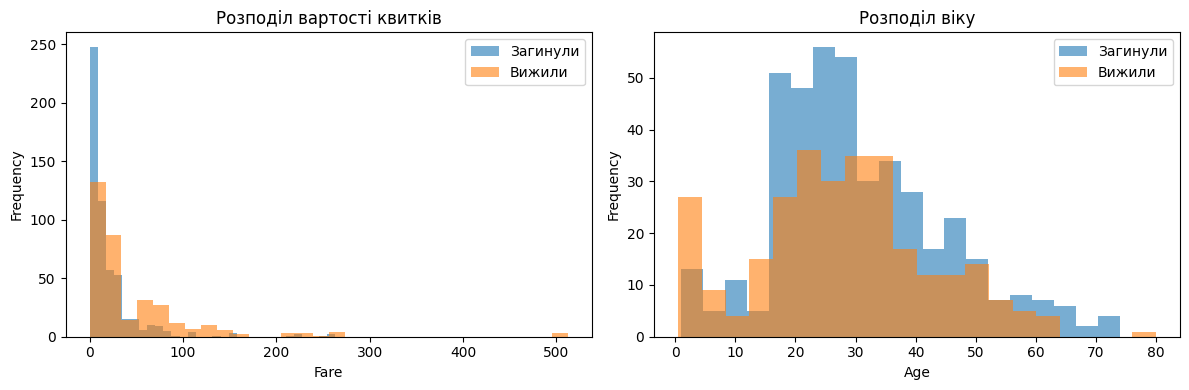

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data.loc[data["Survived"] == 0, "Fare"].plot.hist(bins=30, alpha=0.6, ax=axes[0], label="Загинули")
data.loc[data["Survived"] == 1, "Fare"].plot.hist(bins=30, alpha=0.6, ax=axes[0], label="Вижили")
axes[0].set(title="Розподіл вартості квитків", xlabel="Fare")
axes[0].legend()
data.loc[data["Survived"] == 0, "Age"].plot.hist(bins=20, alpha=0.6, ax=axes[1], label="Загинули")
data.loc[data["Survived"] == 1, "Age"].plot.hist(bins=20, alpha=0.6, ax=axes[1], label="Вижили")
axes[1].set(title="Розподіл віку", xlabel="Age")
axes[1].legend()
plt.tight_layout()
mean_age_by_survival = data.groupby("Survived")["Age"].mean().round(2)
display(mean_age_by_survival)
print("Середній вік загиблих вищий:", mean_age_by_survival.loc[0] > mean_age_by_survival.loc[1])

**8. Як відрізняється середній вік чоловіків / жінок в залежності від класу обслуговування? Оберіть правильні твердження:**
- В середньому чоловіки 1-го класу старші 40 років
- В середньому жінки 1-го класу старші 40 років
- Чоловіки всіх класів в середньому старші жінок того ж класу
- В середньому люди в 1 класі старші, ніж в 2-му, а також старші представників 3-го класу

In [21]:
mean_age_by_sex_class = data.groupby(["Sex", "Pclass"])["Age"].mean().round(2)
display(mean_age_by_sex_class)
print("Чоловіки 1-го класу старші 40 років:", mean_age_by_sex_class.loc[("male", 1)] > 40)
print("Жінки 1-го класу старші 40 років:", mean_age_by_sex_class.loc[("female", 1)] > 40)
print("Чоловіки всіх класів старші за жінок того ж класу:", all(mean_age_by_sex_class.loc[("male", c)] > mean_age_by_sex_class.loc[("female", c)] for c in [1, 2, 3]))
mean_age_by_class = data.groupby("Pclass")["Age"].mean()
print("Середній вік зменшується від 1-го до 3-го класу:", mean_age_by_class.loc[1] > mean_age_by_class.loc[2] > mean_age_by_class.loc[3])

Sex     Pclass
female  1         34.61
        2         28.72
        3         21.75
male    1         41.28
        2         30.74
        3         26.51
Name: Age, dtype: float64

Чоловіки 1-го класу старші 40 років: True
Жінки 1-го класу старші 40 років: False
Чоловіки всіх класів старші за жінок того ж класу: True
Середній вік зменшується від 1-го до 3-го класу: True
